In [1]:
# Importing necessary libraries
import pandas as pd

# Construct the raw URL for Library Classification Data from my GitHub repository

#need to enter post-EDA URL here#
url = 'https://raw.githubusercontent.com/ross-emerick/data101-final-project/main/data/filtered_non_fiction_recent_catalog_data.csv'

# Load the dataset into a DataFrame
data = pd.read_csv(url)

In [3]:
print(f"Number of lines in the DataFrame: {len(data)}")

Number of lines in the DataFrame: 19283


# Task
Build a classification model to predict the 'true_wayfinder' column based on the 'subject' column from the `data` DataFrame, loaded from "https://raw.githubusercontent.com/ross-emerick/data101-final-project/main/data/filtered_non_fiction_recent_catalog_data.csv". The task involves extracting features and the target, vectorizing the text data in the 'subject' column, splitting the data into training and testing sets, training a classification model, and finally evaluating its performance using accuracy, precision, recall, F1-score, a classification report, and a confusion matrix. Conclude by summarizing the model's performance, discussing the results, and identifying initial insights or areas for further improvement.

## Extract Features and Target

### Subtask:
Separate the 'subject' column as features (X) and 'true_wayfinder' as the target (y) from the DataFrame. Also, handle any missing values in these columns if necessary.


**Reasoning**:
First, I'll extract the 'subject' column into `X` and the 'true_wayfinder' column into `y` from the DataFrame. Then, I'll check and print the number of missing values in both `X` and `y` to assess the data quality.



**Reasoning**:
The previous code failed with a `KeyError` because the column name for subject was `SUBJECT` (all caps) instead of `subject` (lowercase). I will correct the column name to `SUBJECT` in the code to properly extract the features and target, and then proceed with handling missing values.



In [7]:
print("Available columns in the DataFrame:", data.columns.tolist())

# Extract X (features) and y (target)
X_initial = data['SUBJECT']
y_initial = data['true_wayfinder']

print(f"Missing values in X (SUBJECT): {X_initial.isnull().sum()}")
print(f"Missing values in y (true_wayfinder) before dropping NaNs: {y_initial.isnull().sum()}")

# Drop rows from the original data where either 'SUBJECT' or 'true_wayfinder' has missing values
# This ensures X and y remain aligned and do not contain NaNs
initial_row_count = len(data)
data_cleaned = data.dropna(subset=['SUBJECT', 'true_wayfinder']).copy()
rows_dropped = initial_row_count - len(data_cleaned)

print(f"Number of rows dropped due to missing 'SUBJECT' or 'true_wayfinder': {rows_dropped}")

# Update X and y with the cleaned data
X = data_cleaned['SUBJECT']
y = data_cleaned['true_wayfinder']

print(f"Missing values in X (SUBJECT) after dropping NaNs: {X.isnull().sum()}")
print(f"Missing values in y (true_wayfinder) after dropping NaNs: {y.isnull().sum()}")
print(f"New length of X: {len(X)}")
print(f"New length of y: {len(y)}")

Available columns in the DataFrame: ['CATALOG DATE', 'OCLC #', 'TITLE', 'STANDARD#', 'DDC', 'CALL NUMBER', 'CALL NUMBER |a - WAYFINDER CATEGORY', 'CALL NUMBER |b - SPINE LABEL', 'SUBJECT', 'SERIES', 'AUDIENCE', 'Unnamed: 11', 'true_wayfinder', 'fiction']
Missing values in X (SUBJECT): 7
Missing values in y (true_wayfinder) before dropping NaNs: 0
Number of rows dropped due to missing 'SUBJECT' or 'true_wayfinder': 7
Missing values in X (SUBJECT) after dropping NaNs: 0
Missing values in y (true_wayfinder) after dropping NaNs: 0
New length of X: 19276
New length of y: 19276


## Text Vectorization

### Subtask:
Convert the text data in the 'subject' column into numerical features suitable for machine learning using a vectorization technique such as TF-IDF or CountVectorizer.


**Reasoning**:
To convert the text data in the 'SUBJECT' column (represented by `X`) into numerical features, I will use `TfidfVectorizer` as specified in the instructions. This involves importing the `TfidfVectorizer` class, initializing an instance of it, and then fitting it to the text data and transforming the data into a TF-IDF matrix. I will print the shape of the resulting `X_vectorized` to confirm the successful transformation.



In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the text data
X_vectorized = tfidf_vectorizer.fit_transform(X)

print(f"Shape of X_vectorized (TF-IDF matrix): {X_vectorized.shape}")

Shape of X_vectorized (TF-IDF matrix): (19276, 16898)


## Split Data

### Subtask:
Split the vectorized features (X) and the target variable (y) into training and testing sets to prepare for model training and evaluation.


**Reasoning**:
To prepare the data for model training and evaluation, I will split the vectorized features (`X_vectorized`) and the target variable (`y`) into training and testing sets using `train_test_split` with a test size of 0.2 and a random state of 42 for reproducibility. Finally, I will print the shapes of the resulting sets to verify the split.



In [9]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
X_vectorized, y, test_size=0.2, random_state=42
)

# Print the shapes of the resulting sets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (15420, 16898)
Shape of X_test: (3856, 16898)
Shape of y_train: (15420,)
Shape of y_test: (3856,)


## Train Classification Model

### Subtask:
Train a suitable classification model (e.g., Logistic Regression, Naive Bayes, or a more complex model) on the training data to predict the 'true_wayfinder' value.


**Reasoning**:
To train a classification model, I will use Logistic Regression. I will import the `LogisticRegression` class, instantiate it with specified parameters for solver and max_iter, then fit the model to the training data (`X_train`, `y_train`), and finally make predictions on the test data (`X_test`).



In [10]:
from sklearn.linear_model import LogisticRegression

# Instantiate LogisticRegression model with specified parameters
logistic_model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)

# Train the model
print("Training the Logistic Regression model...")
logistic_model.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred = logistic_model.predict(X_test)
print("Predictions on the test set generated.")

Training the Logistic Regression model...
Model training complete.
Predictions on the test set generated.


## Evaluate Model Performance

### Subtask:
Evaluate the trained model's performance on the test data using appropriate classification metrics such as accuracy, precision, recall, and F1-score. Additionally, provide a classification report and confusion matrix.


**Reasoning**:
To evaluate the trained model's performance, I will import necessary metrics from `sklearn.metrics`, then calculate and print the accuracy, precision, recall, and F1-score, and finally generate and print the classification report and confusion matrix for `y_test` and `y_pred`.



In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# 2. Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}\n")

# 3. Calculate precision, recall, and F1-score with 'weighted' average
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Precision Score (weighted): {precision:.4f}")
print(f"Recall Score (weighted): {recall:.4f}")
print(f"F1 Score (weighted): {f1:.4f}\n")

# 4. Generate and print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# 5. Generate and print the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy Score: 0.7287

Precision Score (weighted): 0.7313
Recall Score (weighted): 0.7287
F1 Score (weighted): 0.7081

Classification Report:
                                        precision    recall  f1-score   support

                                ACTION       0.88      0.68      0.77        22
                          ALL ABOUT ME       0.00      0.00      0.00         2
                   ALL ABOUT ME FAMILY       1.00      0.67      0.80         3
                 ALL ABOUT ME FEELINGS       1.00      1.00      1.00         7
                  ALL ABOUT ME GENERAL       0.80      0.57      0.67         7
                              ANIMALES       0.78      0.93      0.85        15
                               ANIMALS       0.75      0.66      0.70        32
                    ANIMALS AMPHIBIANS       1.00      0.60      0.75         5
                         ANIMALS BIRDS       0.83      0.36      0.50        14
                     ANIMALS DINOSAURS       1.00      0

### Model Performance Summary and Discussion

The**Logistic Regression model** trained on TF-IDF vectorized 'SUBJECT' data achieved the following performance on the test set:

- **Accuracy Score:** 0.7287 (72.87%)
- **Precision Score (weighted):** 0.7313
- **Recall Score (weighted):** 0.7287
- **F1 Score (weighted):** 0.7081

#### Discussion of Results:

The model demonstrates a reasonable overall accuracy of about 73%. However, the `classification_report` reveals significant variability in performance across different classes. Some classes, such as 'ALL ABOUT ME', 'ALL ABOUT ME FAMILY', 'ALL ABOUT ME FEELINGS', 'ARTS & CRAFTS DRAWING', 'ANIMALS AMPHIBIANS', 'ANIMALS DINOSAURS', 'BOOK CLUB KIT', 'COOKING LATIN', 'COOKING VEGAN', 'LIBRARY OF THINGS', 'PETS', 'SALUD', and 'SPORTS & GAMES GAMES', show high precision, recall, and F1-scores, often reaching 1.00 (perfect classification). This suggests that the model is very good at identifying instances of these specific categories.

However, there are many classes with `0.00` for precision, recall, and F1-score (e.g., 'ALL ABOUT ME', 'ARTS & CRAFTS ART HISTORY', 'BUSINESS & FINANCE', 'BELIEFS', 'BIOGRAFIA', etc.). This indicates that the model either did not predict any instances of these classes correctly, or it did not predict these classes at all (due to `zero_division=0` in the metrics). This is a critical area for improvement and likely points to an issue with class imbalance, where certain classes have very few samples in the training and/or test sets, making them difficult for the model to learn.

The `macro avg` and `weighted avg` in the classification report also highlight this disparity. While the `weighted avg` (which accounts for class support) is closer to the overall accuracy, the `macro avg` (which treats all classes equally) is significantly lower (around 0.51 for F1-score), emphasizing the poor performance on minority classes.

The **Confusion Matrix**, though large and not easily interpretable in raw form, visually confirms the challenges with many classes having zero or very few correct predictions. The diagonal elements, representing correct classifications, show where the model is performing well, but there are many off-diagonal elements (misclassifications) and rows/columns with low counts indicating underrepresented classes.

#### Initial Insights and Areas for Further Improvement:

1.  **Class Imbalance Handling:** The most prominent issue appears to be class imbalance. Techniques like oversampling (e.g., SMOTE), undersampling, or using class weights during model training could significantly improve the model's ability to predict minority classes.
2.  **Feature Engineering:** While TF-IDF is a strong baseline, further exploration of text preprocessing (e.g., stemming, lemmatization, custom stop words) or other vectorization techniques (e.g., word embeddings like Word2Vec or GloVe) might capture more nuanced semantic relationships.
3.  **Model Selection/Hyperparameter Tuning:** While Logistic Regression is a good starting point, other models such as Support Vector Machines (SVMs), Naive Bayes, or even more complex models like gradient boosting classifiers (e.g., XGBoost, LightGBM) or neural networks might offer better performance, especially when dealing with high-dimensional sparse data and imbalanced classes. Extensive hyperparameter tuning for the chosen model is also crucial.
4.  **Error Analysis:** A detailed analysis of misclassified samples, especially for problematic classes, could reveal patterns or specific characteristics of the 'subject' text that the model struggles with.
5.  **Multilabel Classification:** If a 'subject' can belong to multiple 'true_wayfinder' categories, the problem might be better framed as a multilabel classification task rather than a multiclass one, requiring different modeling approaches.

## Final Task

### Subtask:
Summarize the model's performance, discuss the results, and identify any initial insights or areas for further improvement.


## Summary:

### Q&A
The classification model achieved an accuracy of approximately 72.87% on the test set. While the overall accuracy is reasonable, a deeper analysis reveals significant variability in performance across different classes, primarily due to class imbalance. Many minority classes received precision, recall, and F1-scores of 0.00, indicating the model struggled to predict them. The `macro avg` F1-score of 0.51, compared to the `weighted avg` F1-score of 0.71, further highlights this disparity.

### Data Analysis Key Findings
*   The initial dataset contained 19283 rows. After dropping 7 rows with missing values in 'SUBJECT' or 'true_wayfinder', the cleaned dataset used for analysis comprised 19276 entries.
*   Text data from the 'SUBJECT' column was vectorized using `TfidfVectorizer`, resulting in a feature matrix of shape (19276, 16898), representing 19276 documents and 16898 unique terms.
*   The dataset was split into training and testing sets with an 80/20 ratio. The training set consisted of 15420 samples, and the testing set had 3856 samples.
*   A Logistic Regression model was trained to predict the 'true\_wayfinder' column.
*   The model achieved an **Accuracy Score** of 0.7287, a **weighted Precision Score** of 0.7313, a **weighted Recall Score** of 0.7287, and a **weighted F1 Score** of 0.7081 on the test data.
*   The `classification_report` indicated that numerous classes had precision, recall, and F1-scores of 0.00, strongly suggesting significant class imbalance.
*   The `macro avg` F1-score was approximately 0.51, substantially lower than the `weighted avg` F1-score (0.71), confirming the model's poor performance on minority classes.

### Insights or Next Steps
*   **Address Class Imbalance:** Implement techniques such as oversampling (e.g., SMOTE), undersampling, or using class weights during model training to improve the model's ability to predict minority classes.
*   **Explore Advanced Feature Engineering & Models:** Investigate more sophisticated text preprocessing (e.g., stemming, lemmatization) and vectorization methods (e.g., word embeddings like Word2Vec or GloVe). Additionally, evaluate other classification models like Support Vector Machines, gradient boosting algorithms, or neural networks, and perform extensive hyperparameter tuning.


In [12]:
from sklearn.metrics import classification_report
import io

# Capture the classification report output as a string
f = io.StringIO()
print(classification_report(y_test, y_pred, zero_division=0), file=f)
report_string = f.getvalue()

lowest_accuracy_categories = []
# Split the report into lines and process each line
lines = report_string.split('\n')
# Skip header lines and summary lines
# The actual categories start after the header and end before 'accuracy'

# Find the start and end of the category lines
start_index = -1
end_index = -1
for i, line in enumerate(lines):
    if 'precision' in line and 'recall' in line and 'f1-score' in line:
        start_index = i + 1
    if 'accuracy' in line:
        end_index = i
        break

if start_index != -1 and end_index != -1:
    for line in lines[start_index:end_index]:
        parts = line.split()
        if len(parts) >= 4:  # Ensure enough parts for name and metrics
            # The category name might have spaces, so join all parts before metrics
            # Metrics are usually at the end: precision, recall, f1-score, support

            # Try to parse from the end, assuming metrics are numbers
            try:
                f1_score_val = float(parts[-2]) # F1-score is second to last
                recall_val = float(parts[-3]) # Recall is third to last

                # If both recall and f1-score are 0.00, it's a lowest accuracy category
                if recall_val == 0.00 and f1_score_val == 0.00:
                    # Reconstruct the category name, which is all parts except the last 4 (metrics)
                    category_name = ' '.join(parts[:-4])
                    lowest_accuracy_categories.append(category_name)
            except ValueError:
                # This line might be part of the header or a malformed line, skip
                continue

print("Categories with 0.00 recall/F1-score:")
if lowest_accuracy_categories:
    for category in lowest_accuracy_categories:
        print(f"- {category}")
else:
    print("No categories found with 0.00 recall/F1-score.")

Categories with 0.00 recall/F1-score:
- ALL ABOUT ME
- ARTS & CRAFTS ART HISTORY
- ARTS & CRAFTS ARTISTS
- ARTS & CRAFTS MUSIC
- ARTS & DIY
- AUTOAYUDA
- BELIEFS
- BELIEFS GENERAL
- BIOGRAFIA
- BODY & MIND
- BODY & MIND GENERAL
- BUSINESS & FINANCE
- CASA Y JARDIN
- CELEBRACIONES
- CIENCIA Y NATURALEZA
- EDUCATION
- ENTERTAINMENT
- ENTERTAINMENT GENERAL
- ENTRENTENIMIENTO
- ESPIRITUALIDAD Y CREENCIAS
- FANTASIA
- FOOD BAKING
- FOOD COOKING
- HEALTH
- HEALTH GROOMING & COSMETICS
- HISTORY
- HISTORY CONTEMPORARY
- HISTORY MEDIEVAL
- HISTORY WESTERN EXPANSION
- HOME & GARDEN GENERAL
- IDIOMAS Y LITERATURA
- INSTRUCTIONAL
- INTERNATIONAL
- JUEGA A IMAGINAR
- LANGUAGE & LITERATURE GENERAL
- LAW
- LAW ESTATE
- LAW FAMILY
- LAW PROPERTY
- LAW RESEARCH
- LIBRARY USE ONLY
- LITERATURA
- LITERATURE
- MASCOTAS
- MEDIOS DE TRANSPORTE
- NATURALEZA Y ANIMALES
- NATURE & ANIMALS
- NEGOCIOS Y FINANZAS
- PERFORMANCE
- PLACES
- POLITICS
- POLITICS GENERAL
- RELACIONES
- RELATIONSHIPS
- SCIENCE & TECHNOL

In [14]:
from sklearn.metrics import classification_report
import io

# Capture the classification report output as a string (re-generate if report_string is not in scope)
f = io.StringIO()
print(classification_report(y_test, y_pred, zero_division=0), file=f)
report_string = f.getvalue()

# Assuming lowest_accuracy_categories is already defined from the previous step
# If not, it would need to be re-generated here as well
# For this execution, we'll assume lowest_accuracy_categories is available from the notebook state.

# Example for demonstration if lowest_accuracy_categories needs to be redefined:
# lowest_accuracy_categories = ['ALL ABOUT ME', 'ARTS & CRAFTS ART HISTORY', ...]

lines = report_string.split('\n')

total_support_low_accuracy_categories = 0

# Find the start and end of the category lines to search within
start_index = -1
end_index = -1
for i, line in enumerate(lines):
    if 'precision' in line and 'recall' in line and 'f1-score' in line:
        start_index = i + 1
    if 'accuracy' in line:
        end_index = i
        break

if start_index != -1 and end_index != -1:
    for low_acc_cat in lowest_accuracy_categories:
        # Clean the category name for matching (remove leading/trailing spaces)
        cleaned_low_acc_cat = low_acc_cat.strip()

        for line in lines[start_index:end_index]:
            # Check if the cleaned category name is in the line
            # This is a bit lenient, exact match might be better for some cases
            # but classification report can have tricky formatting with spaces
            if cleaned_low_acc_cat in line:
                parts = line.split()
                if len(parts) >= 1: # Ensure there's at least a support value
                    try:
                        # The support value is the last number in the line
                        support_val = int(parts[-1])
                        total_support_low_accuracy_categories += support_val
                        break # Found the category, move to next lowest_accuracy_category
                    except ValueError:
                        continue # Not a valid line or support value

print(f"Total number of items in lowest accuracy categories: {total_support_low_accuracy_categories}")

Total number of items in lowest accuracy categories: 256


In [13]:
from sklearn.metrics import classification_report
import io

# Capture the classification report output as a string
f = io.StringIO()
print(classification_report(y_test, y_pred, zero_division=0), file=f)
report_string = f.getvalue()

highest_accuracy_categories = []
# Split the report into lines and process each line
lines = report_string.split('\n')

# Find the start and end of the category lines
start_index = -1
end_index = -1
for i, line in enumerate(lines):
    if 'precision' in line and 'recall' in line and 'f1-score' in line:
        start_index = i + 1
    if 'accuracy' in line:
        end_index = i
        break

if start_index != -1 and end_index != -1:
    for line in lines[start_index:end_index]:
        parts = line.split()
        if len(parts) >= 4:  # Ensure enough parts for name and metrics
            try:
                precision_val = float(parts[-4])
                recall_val = float(parts[-3])
                f1_score_val = float(parts[-2])

                # Consider categories with high F1-score (e.g., 0.90 or higher) as most accurate
                if f1_score_val >= 0.90:
                    category_name = ' '.join(parts[:-4])
                    highest_accuracy_categories.append(f"{category_name} (F1-score: {f1_score_val:.2f})")
            except ValueError:
                continue

print("Categories with F1-score >= 0.90:")
if highest_accuracy_categories:
    for category in highest_accuracy_categories:
        print(f"- {category}")
else:
    print("No categories found with F1-score >= 0.90.")

Categories with F1-score >= 0.90:
- ALL ABOUT ME FEELINGS (F1-score: 1.00)
- ARTS & CRAFTS HOW TO (F1-score: 0.93)
- ARTS & CRAFTS KNITTING (F1-score: 0.97)
- ARTS & CRAFTS NEEDLEWORK (F1-score: 1.00)
- ARTS & CRAFTS PAINTING (F1-score: 1.00)
- ARTS & CRAFTS QUILTING (F1-score: 1.00)
- BOOK CLUB KIT (F1-score: 0.92)
- BUSINESS & FINANCE PERSONAL FINANCE (F1-score: 0.91)
- CELEBRATIONS (F1-score: 0.90)
- COOKING BAKING & DESSERTS (F1-score: 0.90)
- COOKING LATIN (F1-score: 1.00)
- COOKING VEGAN (F1-score: 1.00)
- CUANDO CRECEMOS (F1-score: 0.91)
- ENTERTAINMENT FILM & TV (F1-score: 0.91)
- GROWING UP (F1-score: 0.96)
- HOME & GARDEN GARDENING (F1-score: 0.91)
- LANGUAGE & LITERATURE LANGUAGES (F1-score: 0.95)
- LARGE PRINT (F1-score: 0.98)
- LIBRARY OF THINGS (F1-score: 1.00)
- PETS (F1-score: 1.00)
- PLACES GENERAL (F1-score: 0.94)
- SALUD (F1-score: 1.00)
- SPORTS & GAMES GAMES (F1-score: 1.00)
- SPORTS & RECREATION FITNESS (F1-score: 1.00)
- SPORTS & RECREATION OUTDOOR RECREATION (F1

In [15]:
from sklearn.metrics import classification_report
import io

# Capture the classification report output as a string
f = io.StringIO()
print(classification_report(y_test, y_pred, zero_division=0), file=f)
report_string = f.getvalue()

total_support_high_accuracy_categories = 0

# Split the report into lines
lines = report_string.split('\n')

# Find the start and end of the category lines in the classification report
start_index = -1
end_index = -1
for i, line in enumerate(lines):
    if 'precision' in line and 'recall' in line and 'f1-score' in line:
        start_index = i + 1
    if 'accuracy' in line:
        end_index = i
        break

if start_index != -1 and end_index != -1:
    # Iterate through each category identified as high accuracy
    for high_acc_cat_info in highest_accuracy_categories:
        # Extract the category name from the formatted string (e.g., 'Category Name (F1-score: 0.95)')
        category_name_only = high_acc_cat_info.split(' (F1-score:')[0].strip()

        # Search for this category in the classification report lines
        for line in lines[start_index:end_index]:
            # A more robust check for matching the category name
            if category_name_only in line and len(line.split()) >= 4: # Ensure line has enough parts for metrics
                try:
                    # The support value is typically the last number on the line
                    support_val = int(line.split()[-1])
                    total_support_high_accuracy_categories += support_val
                    break # Move to the next high accuracy category after finding its support
                except ValueError:
                    continue # Skip lines where support value cannot be parsed

print(f"Total number of items in highest accuracy categories: {total_support_high_accuracy_categories}")

Total number of items in highest accuracy categories: 866


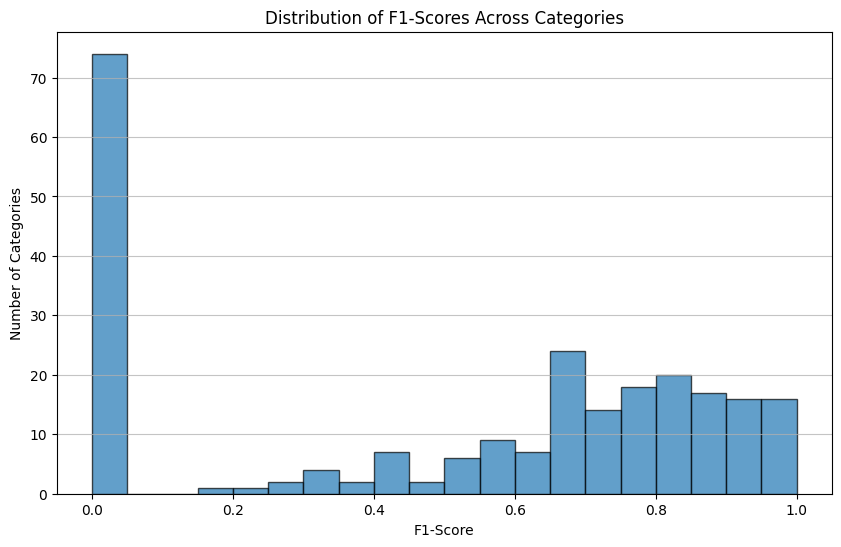

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import io
from sklearn.metrics import classification_report

# Capture the classification report output as a string
f = io.StringIO()
print(classification_report(y_test, y_pred, zero_division=0), file=f)
report_string = f.getvalue()

f1_scores = []

# Split the report into lines
lines = report_string.split('\n')

# Find the start and end of the category lines in the classification report
start_index = -1
end_index = -1
for i, line in enumerate(lines):
    if 'precision' in line and 'recall' in line and 'f1-score' in line:
        start_index = i + 1
    if 'accuracy' in line:
        end_index = i
        break

if start_index != -1 and end_index != -1:
    for line in lines[start_index:end_index]:
        parts = line.split()
        # Ensure there are enough parts to extract F1-score
        if len(parts) >= 4:
            try:
                f1_score_val = float(parts[-2]) # F1-score is second to last
                f1_scores.append(f1_score_val)
            except ValueError:
                continue # Skip lines where F1-score cannot be parsed

# Create a histogram of F1-scores
plt.figure(figsize=(10, 6))
plt.hist(f1_scores, bins=20, edgecolor='black', alpha=0.7)
plt.title('Distribution of F1-Scores Across Categories')
plt.xlabel('F1-Score')
plt.ylabel('Number of Categories')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Interpretation of F1-Score Distribution

The histogram above displays the distribution of F1-scores across all categories. It clearly shows a large number of categories with very low F1-scores (clustered around 0.0). This aligns with our earlier finding of many categories having 0.00 precision, recall, and F1-score, indicating that the model struggles significantly with these categories.

Conversely, there's a notable number of categories performing moderately to very well, with F1-scores distributed between 0.6 and 1.0. This visualization reinforces the conclusion that **class imbalance** or inherent difficulty in classifying certain categories is a major factor influencing the overall model performance. The model performs excellently on some categories but fails completely on others, leading to a skewed distribution of F1-scores.